# Q-learning charging behavior analysis

This notebook is the ipynb version of `plot_agent.py`

It:
- loads the trained Q-learning agent (or trains one if the checkpoint is missing);
- rolls the frozen greedy Q-learning policy and the naive immediate-charge policy over the historical nights;
- compares **what the policies actually do**, rather than inspecting the Q-table directly;
- saves every figure as a PNG under `figures/`;


## 1. Imports and output directory

All generated images are written to `figures/` relative to the notebook's working directory.


In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Any, Tuple

import numpy as np
import matplotlib.pyplot as plt

from environment.discrete_env import make_train_val_envs
from agent.baseline import NaiveImmediateChargePolicy, TrainedQPolicy
from agent.rollout_env import rollout, RolloutSignals
from agent.q_learning_agent import QLearning

# Create an output directory for figures.
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ACTION_NAMES = {0: "idle", 1: "half (50%)", 2: "full (100%)"}
ACTION_POWER_KW = {0: 0.0, 1: 5.5, 2: 11.0}
ACTION_COLORS = ["#dddddd", "#f6a04d", "#d1362f"]

# Fixed 07:00 departure: chronological order for the x-axis.
HOUR_ORDER = list(range(17, 24)) + list(range(0, 7))

print(f"Figures will be saved to: {FIGURES_DIR.resolve()}")

Figures will be saved to: C:\unibo\foschi2526\figures


In [2]:
def _reindex_by_hour_order(hours: np.ndarray, values: np.ndarray, agg="mean"):
    """Aggregate `values` by hour-of-day and return them in HOUR_ORDER."""
    out = []
    for h in HOUR_ORDER:
        mask = hours == h
        if mask.sum() == 0:
            out.append(np.nan)
        else:
            out.append(values[mask].mean() if agg == "mean" else values[mask].sum())
    return np.array(out)


## 2. Plot: which action is taken at each wall-clock hour?

The stacked bars show the share of nights on which the agent chooses:
**idle**, **half charge**, or **full charge** at each hour.

The black line gives the mean electricity price for context.


In [3]:
def plot_action_by_hour(sig: RolloutSignals, title: str, filename: str):
    n_hours = len(HOUR_ORDER)
    shares = np.zeros((n_hours, 3))
    mean_price = np.full(n_hours, np.nan)

    for i, h in enumerate(HOUR_ORDER):
        mask = sig.hour_of_day == h
        if mask.sum() == 0:
            continue
        for a in (0, 1, 2):
            shares[i, a] = (sig.action[mask] == a).mean()
        mean_price[i] = sig.price[mask].mean()

    fig, ax = plt.subplots(figsize=(11, 5))
    bottom = np.zeros(n_hours)
    x = np.arange(n_hours)

    for a in (0, 1, 2):
        ax.bar(
            x,
            shares[:, a],
            bottom=bottom,
            color=ACTION_COLORS[a],
            label=ACTION_NAMES[a],
            width=0.85,
        )
        bottom += shares[:, a]

    ax.set_xticks(x)
    ax.set_xticklabels([f"{h:02d}:00" for h in HOUR_ORDER], rotation=45)
    ax.set_ylabel("share of nights")
    ax.set_xlabel("hour of day (arrival window → 07:00 deadline)")
    ax.set_title(title)

    ax2 = ax.twinx()
    ax2.plot(
        x,
        mean_price,
        color="black",
        marker="o",
        ms=4,
        lw=1.5,
        label="mean price (EUR/MWh)",
    )
    ax2.set_ylabel("mean price (EUR/MWh)")

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc="upper center",
        ncol=4,
        fontsize=8,
    )

    fig.tight_layout()
    fig.savefig(FIGURES_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved: {FIGURES_DIR / filename}")
    return fig, ax


## 3. Plot: Q-learning vs naive charging power

This is the direct behavioral comparison: average charging power drawn at each hour by the two policies.


In [4]:
def plot_power_by_hour_comparison(
    agent_sig: RolloutSignals,
    naive_sig: RolloutSignals,
    title: str,
    filename: str,
):
    agent_power = np.array([ACTION_POWER_KW[a] for a in agent_sig.action])
    naive_power = np.array([ACTION_POWER_KW[a] for a in naive_sig.action])

    agent_by_hour = _reindex_by_hour_order(agent_sig.hour_of_day, agent_power)
    naive_by_hour = _reindex_by_hour_order(naive_sig.hour_of_day, naive_power)
    price_by_hour = _reindex_by_hour_order(agent_sig.hour_of_day, agent_sig.price)

    n_hours = len(HOUR_ORDER)
    x = np.arange(n_hours)

    fig, ax1 = plt.subplots(figsize=(11, 5))

    ax1.plot(
        x,
        naive_by_hour,
        color="tab:blue",
        marker="o",
        label="naive — mean charging power (kW)",
    )
    ax1.plot(
        x,
        agent_by_hour,
        color="tab:green",
        marker="o",
        label="Q-learning — mean charging power (kW)",
    )
    ax1.set_ylabel("mean charging power (kW)")
    ax1.set_xlabel("hour of day (arrival window → 07:00 deadline)")
    ax1.set_xticks(x)
    ax1.set_xticklabels([f"{h:02d}:00" for h in HOUR_ORDER], rotation=45)
    ax2 = ax1.twinx()
    ax2.bar(
        x,
        price_by_hour,
        color="grey",
        alpha=0.2,
        label="mean price (EUR/MWh)",
    )
    ax2.set_ylabel("mean price (EUR/MWh)")
    ax2.set_zorder(0)
    ax1.set_zorder(1)
    ax1.patch.set_visible(False)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc="upper center",
        fontsize=8,
    )
    ax1.set_title(title)

    fig.tight_layout()
    fig.savefig(FIGURES_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved: {FIGURES_DIR / filename}")
    return fig, ax1


## 4. Plot: price paid conditional on action

This checks whether the trained agent tends to select charging actions at lower prices.


In [5]:
def plot_price_by_action(sig: RolloutSignals, title: str, filename: str):
    fig, ax = plt.subplots(figsize=(7, 4.5))

    data = [sig.price[sig.action == a] for a in (0, 1, 2)]

    bp = ax.boxplot(
        data,
        tick_labels=[ACTION_NAMES[a] for a in (0, 1, 2)],
        patch_artist=True,
        showfliers=False,
    )

    for patch, color in zip(bp["boxes"], ACTION_COLORS):
        patch.set_facecolor(color)

    ax.set_ylabel("price (EUR/MWh)")
    ax.set_title(title)

    fig.tight_layout()
    fig.savefig(FIGURES_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved: {FIGURES_DIR / filename}")
    return fig, ax


## 5. Plot: cumulative cost

Each curve is the cumulative **positive spending** over the validation nights, so a steeper curve means more money spent.


In [6]:
def plot_cumulative_cost(
    *,
    sigs: dict,
    title: str,
    filename: str,
) -> Tuple[Any, Any]:
    fig, ax = plt.subplots(figsize=(11, 4.5))

    for label, sig in sigs.items():
        cumulative_cost = -np.cumsum(sig.episode_total_reward)
        ax.plot(
            np.arange(len(cumulative_cost)),
            cumulative_cost,
            label=label,
        )

    ax.set_xlabel("episode (night) index, chronological")
    ax.set_ylabel("cumulative cost (EUR)")
    ax.set_title(title)
    ax.legend(loc="upper left")

    fig.tight_layout()
    fig.savefig(FIGURES_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved: {FIGURES_DIR / filename}")
    return fig, ax


## 6. Load the environment and trained agent

If `q_agent_checkpoint` exists, it is loaded. Otherwise, the notebook falls back to training a fresh agent using the same logic as the original script.


In [7]:
PRICE_N_BINS = 3
SOC_N_BINS = 10

train_env, val_env = make_train_val_envs(
    "./data/Germany.csv",
    price_n_bins=PRICE_N_BINS,
    soc_n_bins=SOC_N_BINS,
)

try:
    agent, _ = QLearning.load("q_agent_checkpoint")
    print("Loaded trained agent from q_agent_checkpoint/.")
except FileNotFoundError:
    print("No checkpoint found — training a fresh agent (see train_agent.py)...")
    import train_agent as tq

    agent, _, _, _ = tq.train(
        train_env,
        tq.N_TRAINING_EPISODES,
        seed=tq.SEED,
    )

agent_policy = TrainedQPolicy(agent)
naive_policy = NaiveImmediateChargePolicy(
    train_env.quantizers["soc"],
    train_env.target_soc,
)

print("Policies ready.")


Loaded trained agent from q_agent_checkpoint/.
Policies ready.


## 7. Roll both policies over the historical nights

The plots below are based on these rollouts, not on direct inspection of the Q-table.


In [8]:
train_windows = train_env.loader.chronological_episodes(
    "train",
    np.random.default_rng(42),
)
val_windows = val_env.loader.chronological_episodes(
    "val",
    np.random.default_rng(42),
)

sig_agent_train = rollout(
    env=train_env,
    policy=agent_policy,
    episode_windows=train_windows,
    seed=42,
)
sig_naive_train = rollout(
    env=train_env,
    policy=naive_policy,
    episode_windows=train_windows,
    seed=42,
)
sig_agent_val = rollout(
    env=val_env,
    policy=agent_policy,
    episode_windows=val_windows,
    seed=42,
)
sig_naive_val = rollout(
    env=val_env,
    policy=naive_policy,
    episode_windows=val_windows,
    seed=42,
)

print("Rollouts completed.")


Rollouts completed.


## 8. Generate and save all figures

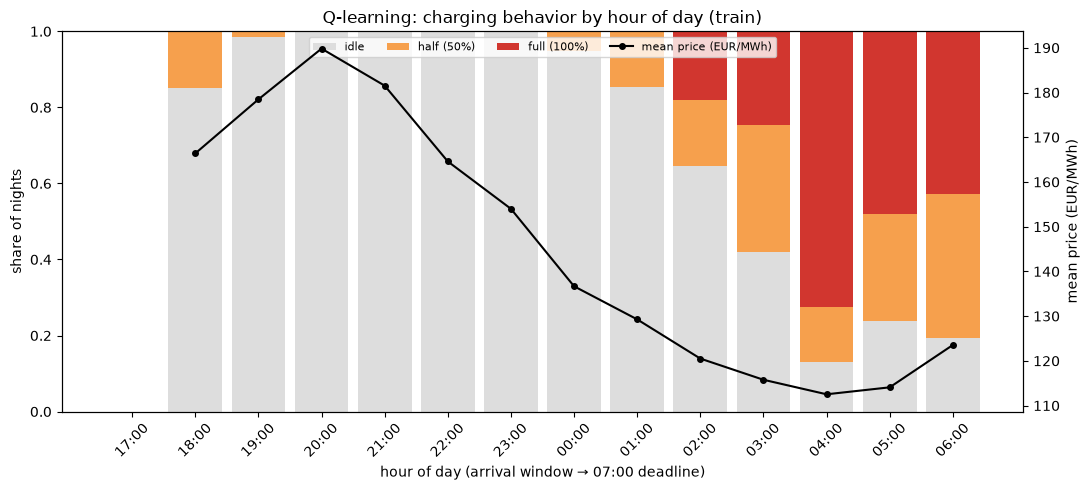

Saved: figures\q_learning_action_by_hour.png


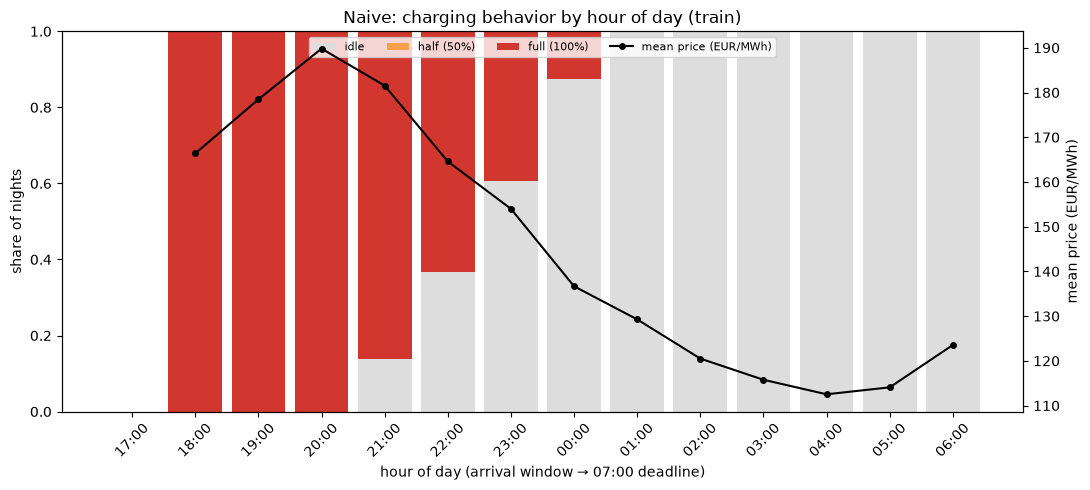

Saved: figures\naive_action_by_hour.png


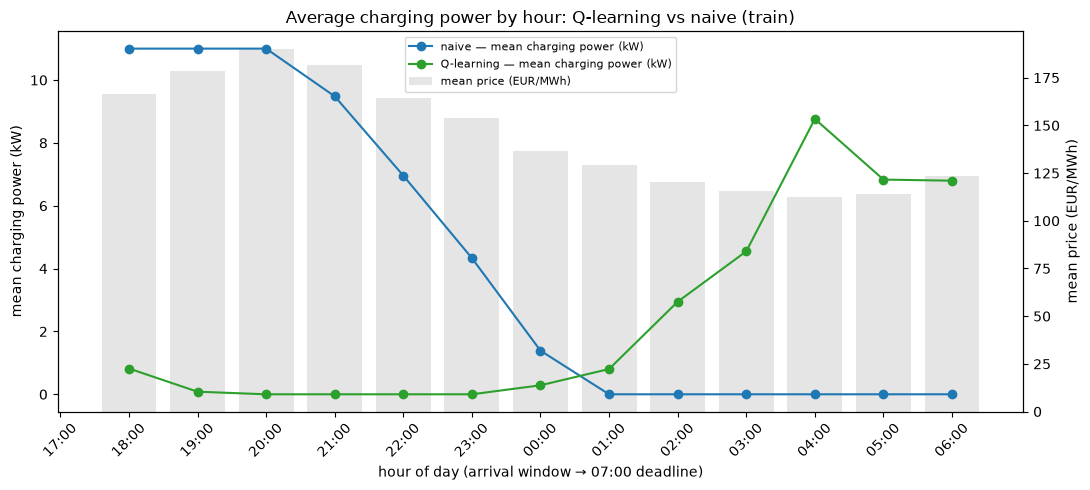

Saved: figures\power_by_hour.png


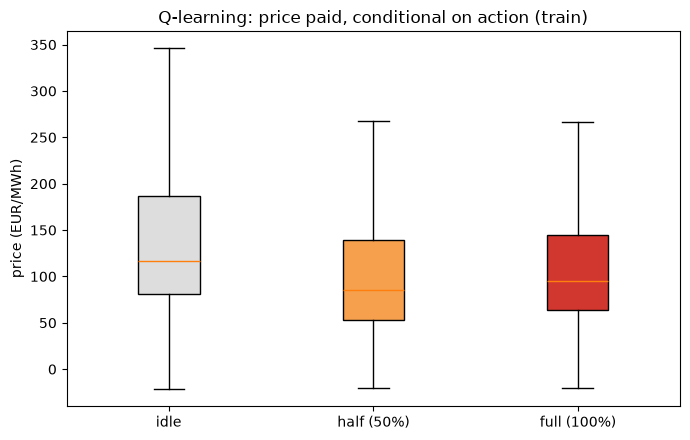

Saved: figures\price_by_action.png


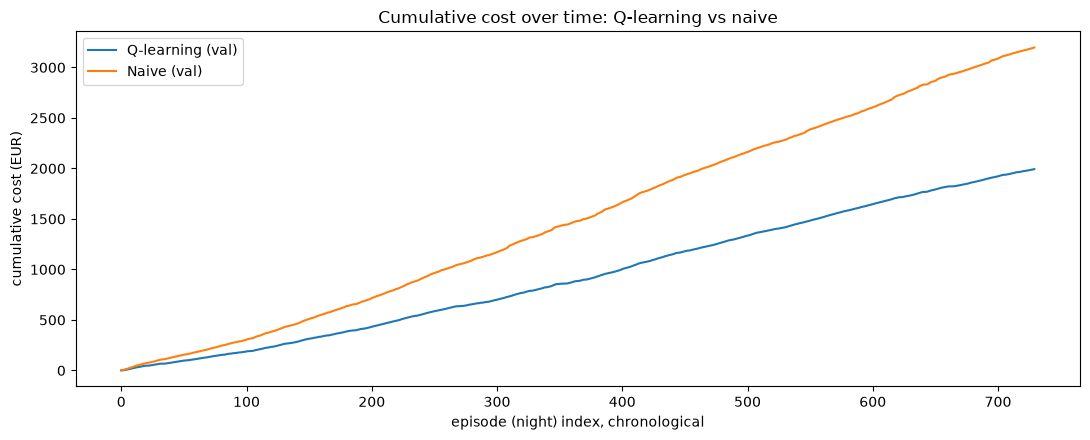

Saved: figures\cumulative_cost.png


(<Figure size 1100x450 with 1 Axes>,
 <Axes: title={'center': 'Cumulative cost over time: Q-learning vs naive'}, xlabel='episode (night) index, chronological', ylabel='cumulative cost (EUR)'>)

In [9]:
plot_action_by_hour(
    sig_agent_train,
    title="Q-learning: charging behavior by hour of day (train)",
    filename="q_learning_action_by_hour.png",
)

plot_action_by_hour(
    sig_naive_train,
    title="Naive: charging behavior by hour of day (train)",
    filename="naive_action_by_hour.png",
)

plot_power_by_hour_comparison(
    sig_agent_train,
    sig_naive_train,
    title="Average charging power by hour: Q-learning vs naive (train)",
    filename="power_by_hour.png",
)

plot_price_by_action(
    sig_agent_train,
    title="Q-learning: price paid, conditional on action (train)",
    filename="price_by_action.png",
)

plot_cumulative_cost(
    sigs={
        "Q-learning (val)": sig_agent_val,
        "Naive (val)": sig_naive_val,
    },
    title="Cumulative cost over time: Q-learning vs naive",
    filename="cumulative_cost.png",
)
